## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.15 解碼與生成，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 19｜大型語言模型_生成與聊天系統

在固定 logits 上比較 greedy 與 top-k 抽樣，觀察溫度的影響。

對應 `slides/19_大型語言模型_生成與聊天系統.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/15_transformers_for_nlp_and_chatbots.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Decoder-only Transformers、generation 與 chatbot 區段。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
vocab = np.array(['資料', '模型', '學習', '風險', '答案'])
logits = np.array([1.2, 2.4, 1.8, 0.4, 1.0])
def probs(temp):
    z = logits / temp; p = np.exp(z-z.max()); return p/p.sum()
def sample_top_k(temp=1.0, k=3, n=8):
    p = probs(temp); ids = np.argsort(p)[-k:]; q = p[ids]/p[ids].sum()
    return rng.choice(vocab[ids], size=n, p=q)
rows = pd.DataFrame({'token': vocab, 'p_T0.7': probs(.7), 'p_T1.3': probs(1.3)})
print('greedy:', vocab[np.argmax(logits)])
print('top-k sample:', ' '.join(sample_top_k()))
rows.round(3)

greedy: 模型
top-k sample: 模型 學習 模型 模型 資料 模型 模型 模型


,token,p_T0.7,p_T1.3
0,資料,0.100,0.154
1,模型,0.556,0.387
2,學習,0.236,0.244
3,風險,0.032,0.083
4,答案,0.075,0.132


## 執行結果圖

/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 36039 (\N{CJK UNIFIED IDEOGRAPH-8CC7}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 26009 (\N{CJK UNIFIED IDEOGRAPH-6599}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Use

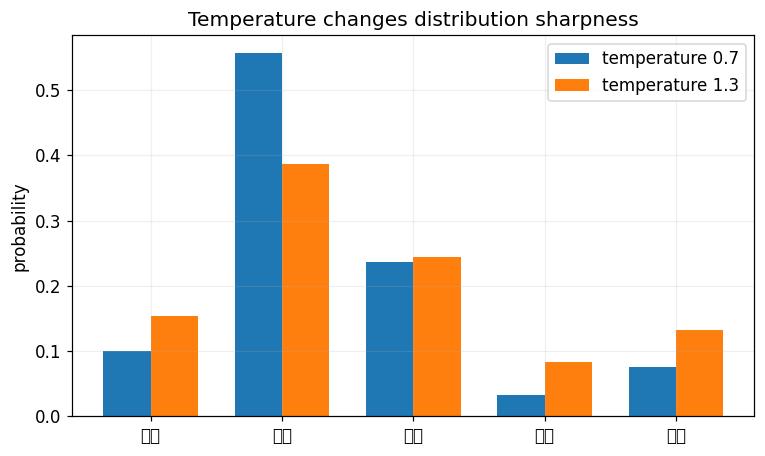

In [3]:
x = np.arange(len(vocab)); w = .36
plt.bar(x-w/2, probs(.7), w, label='temperature 0.7')
plt.bar(x+w/2, probs(1.3), w, label='temperature 1.3')
plt.xticks(x, vocab); plt.ylabel('probability'); plt.title('Temperature changes distribution sharpness')
plt.legend()
savefig('19_sampling_demo')
report('llm_sampling', {'vocab': vocab.tolist(), 'p_07': probs(.7).tolist(), 'p_13': probs(1.3).tolist()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。